# LDV Cable-Coupling — Amplitude Analysis

A broad overview of the **displacement and strain amplitudes** induced in every
configuration of Experiment 2. Where the coupling notebooks report *ratios*
($\eta$, $\Theta$, transfer functions), this notebook reports the raw
**amplitudes** that feed them — intended as **reference values for numerical
simulations** and to expose behavioural differences between cables, gaps and sag
states.

### Experiment setup
One cable end is driven by the shaker; the other is clamped fixed a set distance
away. The strain-transfer efficiency is referenced to the **cable endpoint
sensors** (not the shaker's own amplitude). This notebook therefore reports:

- **$\Delta u_\mathrm{ends}$** — relative axial displacement between the two
  endpoint sensors spanning the hanging segment (the differential that strains
  the cable);
- **$\varepsilon_\mathrm{ends} = \Delta u_\mathrm{ends} / L_\mathrm{ends}$** —
  the segment strain (relative displacement ÷ endpoint spacing);
- the **shaker input $\delta L$** vs the **first cable sensor** displacement and
  the **transfer** between them (how much drive reaches the cable).

### Where each value comes from

All amplitudes are produced by [`ldv_analysis/amplitude.py`](ldv_analysis/amplitude.py).
Two extraction methods are available via `AMP_METHOD`: a fast **frequency-domain**
reader (`'fd'`, the default) and an exact **time-domain** Hilbert-envelope reader
(`'median'`/`'peak'`/`'rms'`), the latter sharing the pipeline of
[`analysis.per_frequency_qc`](ldv_analysis/analysis.py) — so they agree with the
$\eta$/QC notebooks. Both return the same quantities:

| Value | Symbol | Retrieved from |
|---|---|---|
| Endpoint relative displacement | $\Delta u_\mathrm{ends}$ | `amplitude.amplitude_sweep(cfg)['disp_ends']` |
| Endpoint strain | $\varepsilon_\mathrm{ends}$ | `...['strain_ends']`  (= `disp_ends`/`L_ends`) |
| Shaker input displacement | $\delta L$ | `...['disp_shaker']` |
| First cable-sensor displacement | $u_{\parallel,\mathrm{first}}$ | `...['disp_first']` |
| Shaker → first-sensor transfer | $T$ | `...['transfer_first']`  (energy $\propto T^2$) |
| Band mean over $<25$ Hz | — | `amplitude.band_mean_amplitude(cfg, 0, 25)` |

**How one amplitude is obtained** — `amplitude.amplitude_at_frequency(cfg, f)`:

*Frequency-domain* (`'fd'`, default): integrate the velocities to displacement
**once** per dataset (`signal.integrate_fft`) and project onto the chord
(`geometry.project_onto_chord`); then at each frequency window the signal around
`config.sweep_time_of_frequency(f)` and recover the amplitude from the FFT
**band energy** over $\pm$`config.BANDWIDTH_ABS_HZ` Hz. No per-frequency bandpass,
so it is ~90× faster and cheap on a dense grid (the
`freqdomain.stft_point_transfer` mechanism, returning an absolute amplitude
instead of a transfer ratio).

*Time-domain* (`'median'`/`'peak'`/`'rms'`): for each frequency bandpass the full
record (`signal.bandpass`, $\pm$`config.BANDWIDTH_ABS_HZ` Hz), window, integrate,
project, and reduce the windowed trace via its Hilbert envelope. Exact for an
isolated tone; reuses `cfg['per_freq']` from the $\eta$/QC notebooks when present.

Both agree to within a few % below ~100 Hz; above that the frequency-domain
**absolute** amplitudes drift (small signals, coarse short-window bins), while the
**transfer ratio** $T$ stays accurate at every frequency.

The **shaker input** $\delta L$ comes from the `*_SHAKER.mat` files:
`io.load_cable_dataset` picks the active shaker channel and stores it as
`cfg['sh_vx/sh_vy/sh_vz']`, which step 3–4 above turn into the chord-projected
$\delta L$ (same reference used by `per_frequency_qc`). The **first cable sensor** is the *driven* endpoint, identified as the endpoint
with the larger broadband motion energy (`amplitude._first_sensor_index`) rather
than from the catalogue's `shaker_end` flag: for every dataset that is `idx_left`
(the smallest-x sensor, ≈ δL), while `idx_right` is the fixed clamp (≈ 0 motion).
Δu_ends and the strain use both endpoints symmetrically, so they are independent
of this choice; only `disp_first` / `transfer_first` depend on it.

> If `per_frequency_qc` has already run for a dataset in this kernel (e.g. from
> `LDV_EtaTheta_Analysis.ipynb`), `cfg['per_freq'][f]` is reused directly — same
> numbers, no recomputation.

| Section | Content |
|---|---|
| 0 | Parameters (edit here) |
| 1 | Imports & dataset selection |
| 2 | Load & geometry |
| 3 | Compute amplitude sweeps (all configs) |
| 4 | Configuration overview: mean displacement / strain for $<25$ Hz |
| 5 | Amplitude vs frequency, 1–500 Hz (all configs overlaid) |
| 6 | Interactive per-configuration viewer |
| 7 | Shaker input vs first cable sensor + transfer |
| 8 | Reference-value export table |


---
## Section 0  Parameters

Edit the values below, then run all cells.

In [ ]:
import numpy as np
# ─── Quasi-static band for the configuration overview (Sections 4 & 7) ──────
F_MIN_LOW = 1.0
F_MAX_LOW = 25.0     # Hz — mean amplitudes are averaged over [F_MIN_LOW, F_MAX_LOW]

# ─── Amplitude extraction method ────────────────────────────────────────────
# How amplitude.amplitude_at_frequency turns each frequency into an amplitude:
#   'fd'     -> FREQUENCY-DOMAIN (default). Integrate each dataset once, then read
#               the tone's band energy from a windowed FFT at the sweep-arrival
#               time. ~90x faster than the time-domain path, high-resolution
#               (cheap on a dense grid) and stable. Matches the time-domain
#               amplitudes to a few % below ~100 Hz; above that the absolute
#               amplitudes drift, while the transfer ratio T stays accurate.
#   'median' -> TIME-DOMAIN. Bandpass the full record per frequency, integrate,
#               take the median of the Hilbert envelope. Exact for an isolated
#               tone but much slower; use for accurate high-frequency amplitudes.
#   'peak' / 'rms' -> time-domain, envelope max / sqrt(2)*RMS.
AMP_METHOD = 'fd'

# ─── Frequency grid for the amplitude sweep ─────────────────────────────────
# None -> config.TARGET_FREQS (dense 2–500 Hz). With AMP_METHOD='fd' the full
# grid is cheap, so Section 5 (amplitude vs frequency) spans the whole band.
# A custom denser grid is also fine, e.g.
#   AMP_FREQS = list(np.arange(2, 100, 1)) + list(np.arange(100, 501, 5))
#AMP_FREQS = list(np.arange(1, 500, 5))
AMP_FREQS = list(np.arange(1, 500, 2))


# ─── Dataset selection ──────────────────────────────────────────────────────
# None -> all sweep datasets (linearity-test recordings excluded).
ACTIVE_LABELS = None
# ACTIVE_LABELS = [f'Cable{i}_10cm' for i in range(1, 8)]     # one gap, all cables
# ACTIVE_LABELS = ['Cable5_5cm', 'Cable5_10cm', 'Cable5_15cm']  # gap sweep

# ─── Static-sag method (only affects geometry: chord_len used downstream) ────
SAG_USE_3D       = True
SAG_USE_PARABOLA = True


---
## Section 1  Imports & dataset selection

In [14]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, analysis, amplitude, plotting, widgets

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.0,
})

labels = config.SWEEP_LABELS if ACTIVE_LABELS is None else ACTIVE_LABELS
DATASETS = config.select_datasets(labels)
freqs = config.TARGET_FREQS if AMP_FREQS is None else AMP_FREQS

print(f'{len(DATASETS)} datasets selected.')
print(f'Amplitude estimator : {AMP_METHOD}')
print(f'Sweep grid          : {len(freqs)} frequencies '
      f'({min(freqs):.0f}–{max(freqs):.0f} Hz)')
print(f'Overview band        : {F_MIN_LOW:.0f}–{F_MAX_LOW:.0f} Hz')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
42 datasets selected.
Amplitude estimator : median
Sweep grid          : 100 frequencies (1–496 Hz)
Overview band        : 1–25 Hz


---
## Section 2  Load & geometry

`io.load_cable_dataset` reads each cable `.mat` **and** its `*_SHAKER.mat`
partner (the active shaker channel → `cfg['sh_vx/sh_vy/sh_vz']`); loads are
cached per kernel session. `analysis.prepare_geometry` sets the chord direction,
`chord_len`, static sag, $\Theta$ and $\eta_\mathrm{pred}$ — the amplitude code
needs `chord_unit`, `idx_left/idx_right` and `shaker_end` from it.

In [15]:
for cfg in DATASETS:
    io.load_cable_dataset(cfg, verbose=False)

for cfg in DATASETS:
    analysis.prepare_geometry(cfg, sag_use_3d=SAG_USE_3D,
                              sag_use_parabola=SAG_USE_PARABOLA)

print(f'Loaded and prepared {len(DATASETS)} datasets.')
print()
for cfg in DATASETS[:3]:
    L_ends = np.linalg.norm(cfg['XYZ'][cfg['idx_right']] - cfg['XYZ'][cfg['idx_left']])
    print(f"  {cfg['label']:26s}  n_sensors={cfg['n_sensors']:2d}  "
          f"L_ends={L_ends*1e3:6.1f} mm  shaker_end={cfg['shaker_end']}")
if len(DATASETS) > 3:
    print(f'  ... ({len(DATASETS)-3} more)')


Loaded and prepared 42 datasets.

  Cable1_5cm                  n_sensors= 9  L_ends=  42.1 mm  shaker_end=right
  Cable1_5cm_Sag              n_sensors= 9  L_ends=  42.1 mm  shaker_end=right
  Cable1_10cm                 n_sensors=17  L_ends=  91.3 mm  shaker_end=right
  ... (39 more)


---
## Section 3  Compute amplitude sweeps

`amplitude.amplitude_sweep(cfg, freqs)` runs `amplitude.amplitude_at_frequency`
at every frequency and stores aligned arrays in `cfg['amp_sweep'][AMP_METHOD]`:
`disp_ends`, `strain_ends`, `disp_shaker`, `disp_first`, `transfer_first`
(plus `f`, `L_ends`).

> With `AMP_METHOD='fd'` (default) each dataset is integrated **once** and every
> per-frequency read is a cheap windowed FFT, so the full 2–500 Hz grid runs in a
> few seconds. The time-domain methods (`'median'`/`'peak'`/`'rms'`) bandpass the
> full record per frequency and are far slower (minutes for all 42 datasets), but
> reuse `cfg['per_freq']` from the η/QC notebooks when available.

> Loading the `.mat` files is the only heavy step (~10–17 MB each); it is cached
> per kernel session, so re-running the sweep with a different `AMP_METHOD` or
> grid is quick.

In [16]:
t0 = time.time()
for cfg in DATASETS:
    amplitude.amplitude_sweep(cfg, freqs=freqs, amp_method=AMP_METHOD)
print(f'Amplitude sweeps done in {time.time()-t0:.1f} s')
print()

# Preview the <25 Hz band means for a few datasets
for cfg in DATASETS[:5]:
    bm = amplitude.band_mean_amplitude(cfg, f_min=F_MIN_LOW, f_max=F_MAX_LOW,
                                       amp_method=AMP_METHOD)
    print(f"  {cfg['label']:26s}  "
          f"Δu_ends={bm['disp_ends_mean']*1e6:8.3f} µm   "
          f"ε_ends={bm['strain_ends_mean']*1e6:8.2f} µε   "
          f"T(sh→1)={bm['transfer_first_mean']:.3f}   (n={bm['n']})")
if len(DATASETS) > 5:
    print(f'  ... ({len(DATASETS)-5} more)')


Amplitude sweeps done in 367.4 s

  Cable1_5cm                  Δu_ends=   0.322 µm   ε_ends=    7.65 µε   T(sh→1)=0.862   (n=5)
  Cable1_5cm_Sag              Δu_ends=   0.592 µm   ε_ends=   14.07 µε   T(sh→1)=0.797   (n=5)
  Cable1_10cm                 Δu_ends=   0.705 µm   ε_ends=    7.72 µε   T(sh→1)=0.806   (n=5)
  Cable1_10cm_Sag             Δu_ends=   1.223 µm   ε_ends=   13.40 µε   T(sh→1)=0.796   (n=5)
  Cable1_15cm                 Δu_ends=   1.153 µm   ε_ends=    8.17 µε   T(sh→1)=0.220   (n=5)
  ... (37 more)


---
## Section 4  Configuration overview — mean displacement / strain ($<25$ Hz)

`plotting.plot_amplitude_overview` reads `amplitude.band_mean_amplitude(cfg, 0,
25)` for every configuration and plots the band-mean amplitude grouped by cable.
Encoding matches the other notebooks: **colour = cable**, **marker = gap**
(◆ 5 cm, ◼ 10 cm, ● 15 cm), **open = intended-sag** variant. Error bars are the
std across the band frequencies.

- Top panel: endpoint relative displacement $\Delta u_\mathrm{ends}$ [µm].
- Bottom panel: endpoint strain $\varepsilon_\mathrm{ends}$ [µε] = $\Delta
  u_\mathrm{ends}/L_\mathrm{ends}$.

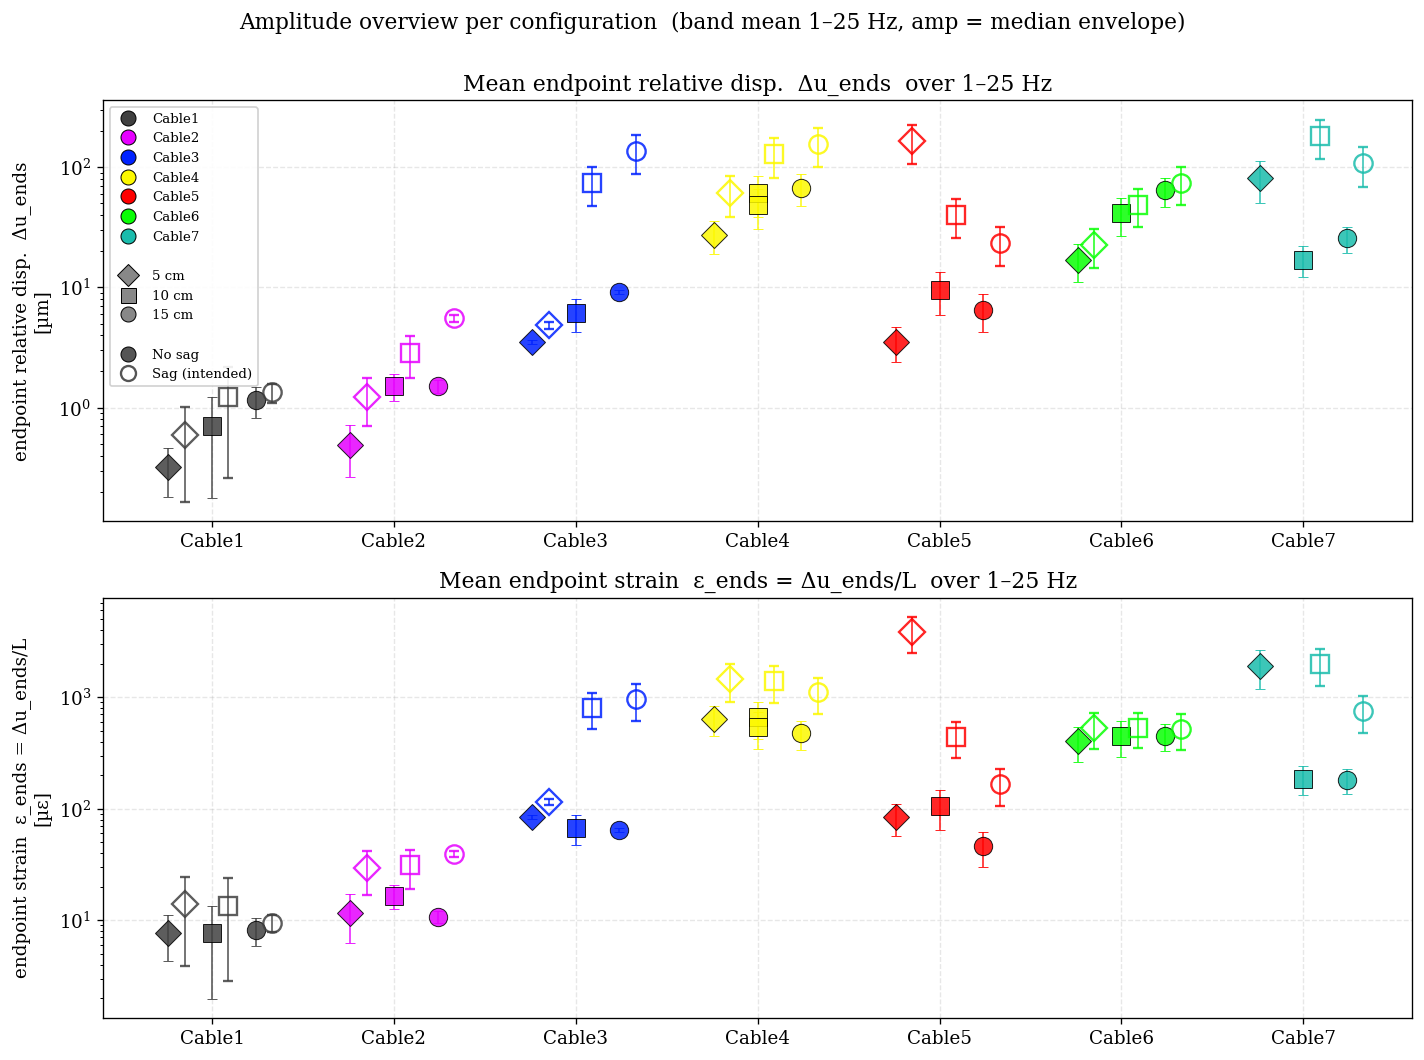

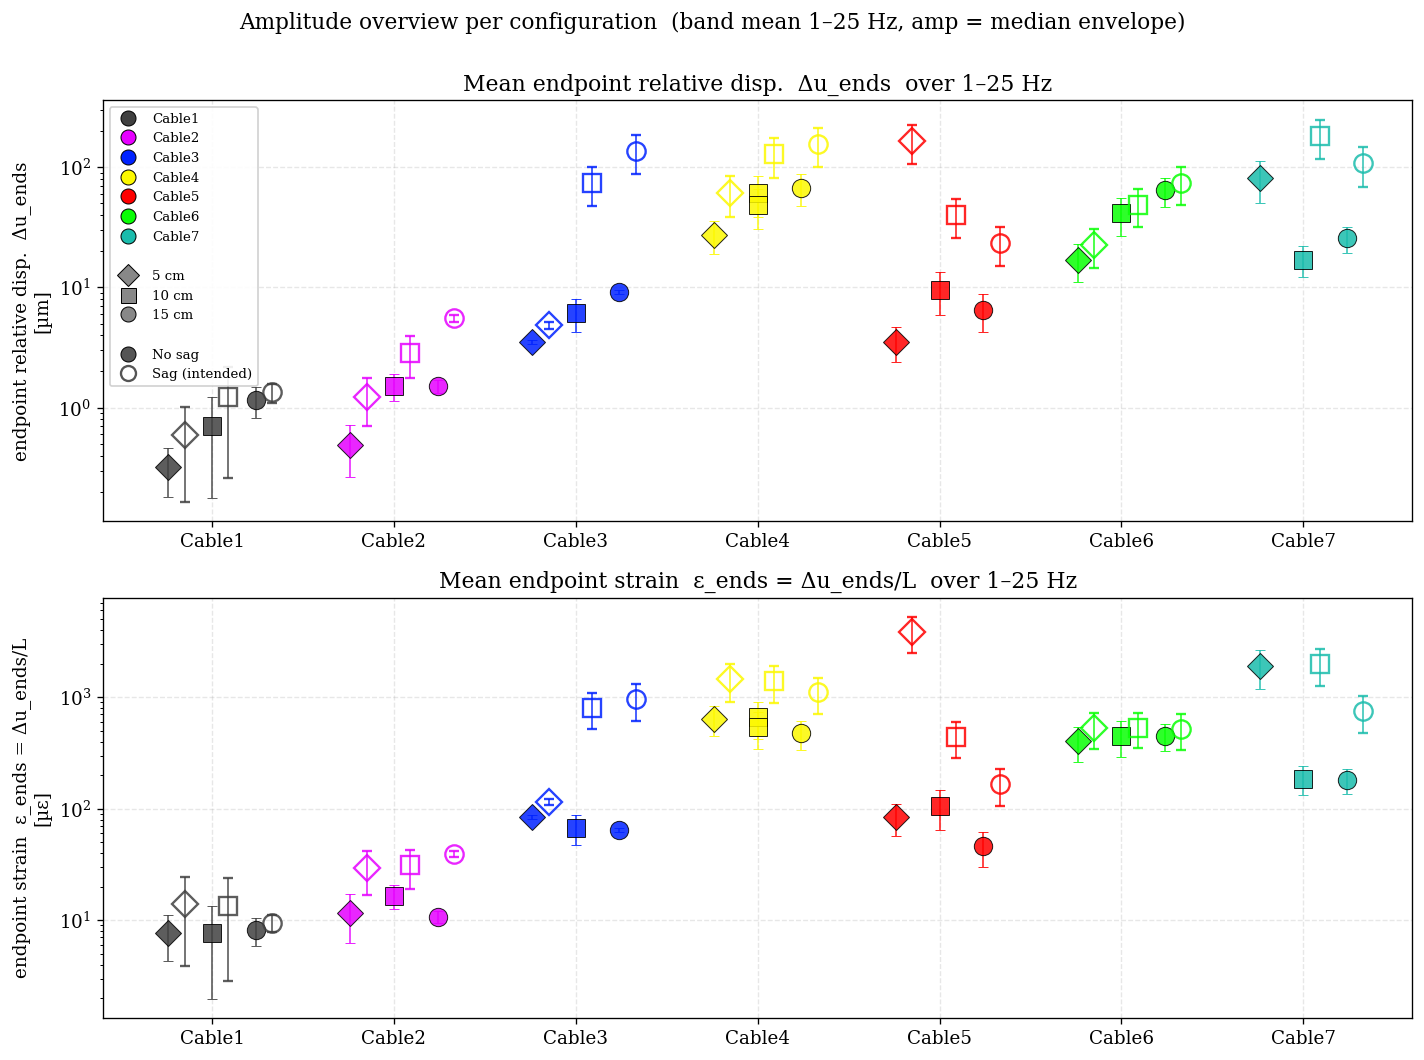

In [18]:
plotting.plot_amplitude_overview(
    DATASETS, f_min=F_MIN_LOW, f_max=F_MAX_LOW, amp_method=AMP_METHOD,
    quantities=('disp_ends', 'strain_ends'), logy=True, freqs=freqs)


Tabulated band-mean reference values (mean ± std over
$[F_\mathrm{MIN\_LOW}, F_\mathrm{MAX\_LOW}]$ Hz), sorted by cable and gap.

In [19]:
from IPython.display import display

rows = []
for cfg in DATASETS:
    bm = amplitude.band_mean_amplitude(cfg, f_min=F_MIN_LOW, f_max=F_MAX_LOW,
                                       amp_method=AMP_METHOD)
    sw = cfg['amp_sweep'][AMP_METHOD]
    L_ends = float(sw['L_ends'][0]) if sw['L_ends'].size else np.nan
    rows.append({
        'Label': cfg['label'],
        'Cable': cfg.get('cable', '?'),
        'Gap [cm]': int(cfg['gap_m'] * 100),
        'Sag': 'yes' if 'Sag' in cfg['label'] else 'no',
        'L_ends [mm]': L_ends * 1e3,
        'Δu_ends [µm]': bm['disp_ends_mean'] * 1e6,
        '± [µm]': bm['disp_ends_std'] * 1e6,
        'ε_ends [µε]': bm['strain_ends_mean'] * 1e6,
        '± [µε]': bm['strain_ends_std'] * 1e6,
        'δL [µm]': bm['disp_shaker_mean'] * 1e6,
        'u_first [µm]': bm['disp_first_mean'] * 1e6,
        'T (sh→1)': bm['transfer_first_mean'],
    })

df_amp = (pd.DataFrame(rows)
          .sort_values(['Cable', 'Gap [cm]', 'Sag'])
          .reset_index(drop=True))
display(df_amp.style
        .format({'L_ends [mm]': '{:.1f}',
                 'Δu_ends [µm]': '{:.3f}', '± [µm]': '{:.3f}',
                 'ε_ends [µε]': '{:.1f}', '± [µε]': '{:.1f}',
                 'δL [µm]': '{:.3f}', 'u_first [µm]': '{:.3f}',
                 'T (sh→1)': '{:.3f}'})
        .background_gradient(subset=['ε_ends [µε]'], cmap='viridis')
        .set_caption(f'Mean induced amplitudes over {F_MIN_LOW:.0f}–{F_MAX_LOW:.0f} Hz '
                     f'(estimator: {AMP_METHOD})'))


,Label,Cable,Gap [cm],Sag,L_ends [mm],Δu_ends [µm],± [µm],ε_ends [µε],± [µε],δL [µm],u_first [µm],T (sh→1)
0,Cable1_5cm,Cable1,5,no,42.1,0.322,0.142,7.7,3.4,0.766,0.647,0.862
1,Cable1_5cm_Sag,Cable1,5,yes,42.1,0.592,0.428,14.1,10.2,1.077,0.835,0.797
2,Cable1_10cm,Cable1,10,no,91.3,0.705,0.526,7.7,5.8,1.109,0.815,0.806
3,Cable1_10cm_Sag,Cable1,10,yes,91.3,1.223,0.964,13.4,10.6,1.770,1.290,0.796
4,Cable1_15cm,Cable1,15,no,141.2,1.153,0.330,8.2,2.3,14.284,2.221,0.220
5,Cable1_15cm_Sag,Cable1,15,yes,141.3,1.345,0.240,9.5,1.7,8.511,1.866,0.216
6,Cable2_5cm,Cable2,5,no,42.1,0.492,0.228,11.7,5.4,2.180,1.084,0.537
7,Cable2_5cm_Sag,Cable2,5,yes,42.1,1.237,0.533,29.4,12.7,5.935,1.659,0.331
8,Cable2_10cm,Cable2,10,no,91.3,1.519,0.374,16.6,4.1,11.380,3.006,0.310
9,Cable2_10cm_Sag,Cable2,10,yes,91.3,2.839,1.088,31.1,11.9,17.605,4.556,0.277


---
## Section 5  Amplitude vs frequency (1–500 Hz)

`plotting.plot_amplitude_vs_frequency` overlays one line per configuration
(reading `cfg['amp_sweep'][AMP_METHOD]`) over the full swept band. Same
colour/marker/fill encoding as Section 4. Change `quantity` to any sweep key
(`disp_ends`, `strain_ends`, `disp_shaker`, `disp_first`, `transfer_first`).

For a per-configuration view instead of the overlay, use the interactive viewer
in Section 6.

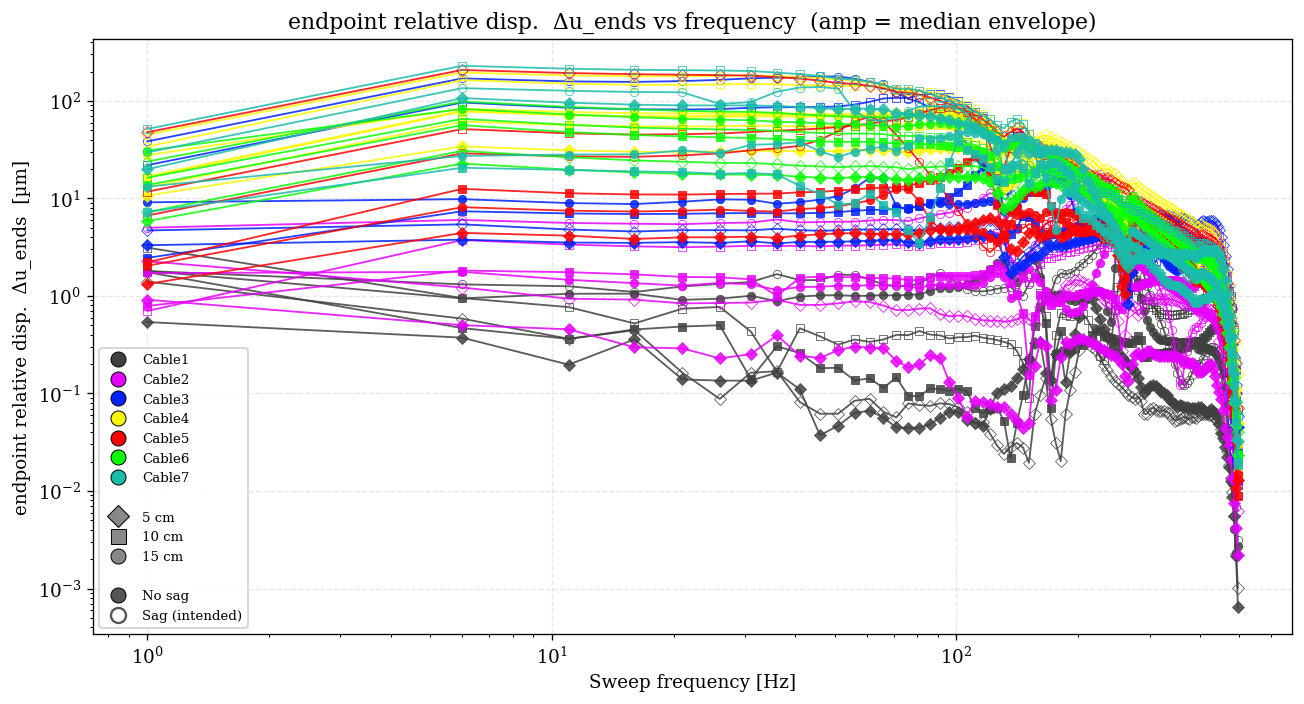

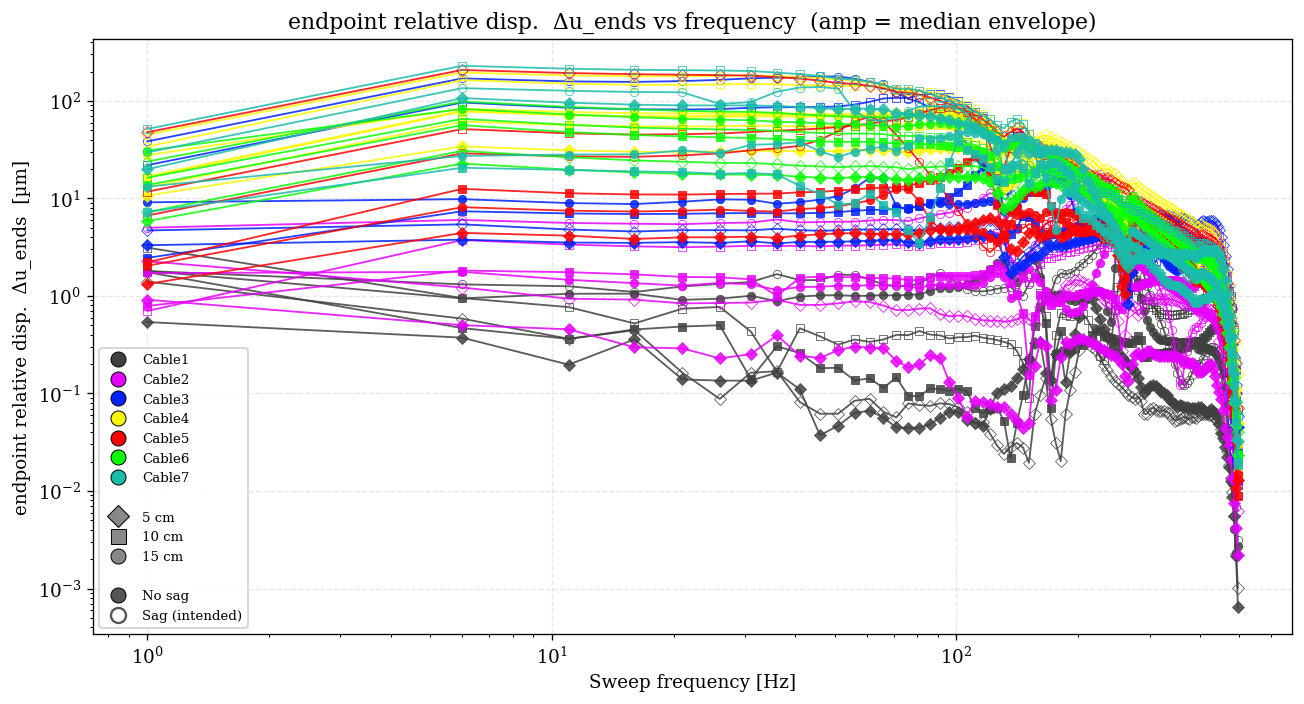

In [20]:
plotting.plot_amplitude_vs_frequency(
    DATASETS, quantity='disp_ends', amp_method=AMP_METHOD, freqs=freqs)


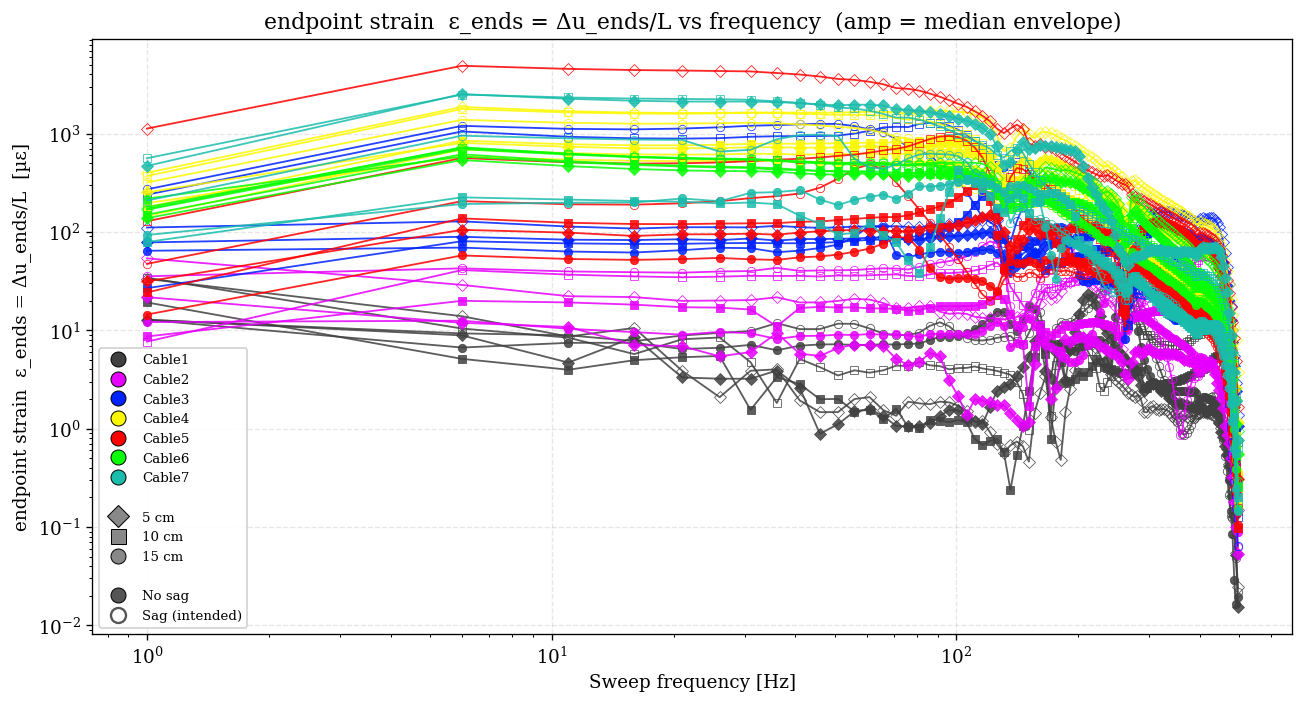

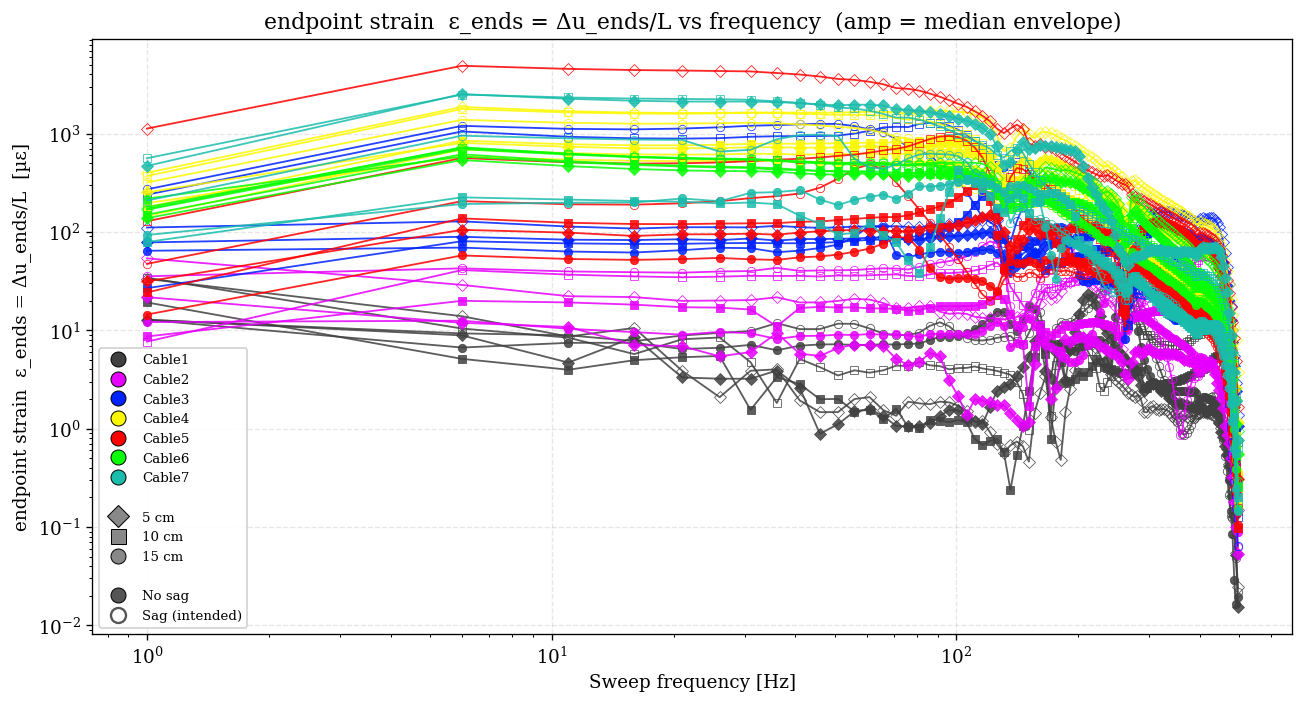

In [21]:
plotting.plot_amplitude_vs_frequency(
    DATASETS, quantity='strain_ends', amp_method=AMP_METHOD, freqs=freqs)


---
## Section 6  Interactive per-configuration viewer

`widgets.amplitude_browser` plots amplitude vs frequency for one selected
configuration (values from `amplitude.amplitude_sweep`). Views:

- **endpoint disp+strain** — $\Delta u_\mathrm{ends}$ [µm] and
  $\varepsilon_\mathrm{ends}$ [µε] on twin axes;
- **shaker vs first sensor** — $\delta L$ and $u_{\parallel,\mathrm{first}}$ [µm]
  overlaid, with the transfer $T$ on a twin axis;
- **all displacements** — $\Delta u_\mathrm{ends}$, $\delta L$ and
  $u_{\parallel,\mathrm{first}}$ together.

In [22]:
widgets.amplitude_browser(DATASETS, amp_method=AMP_METHOD, freqs=freqs)


---
## Section 7  Shaker input vs first cable sensor

`plotting.plot_shaker_transfer` compares the imposed shaker motion $\delta L$
with the displacement that actually reaches the first cable sensor, per
configuration:

- **(a)** band-mean $u_{\parallel,\mathrm{first}}$ vs $\delta L$ (log–log) with
  the 1:1 line — points **below** the line lose amplitude at the first contact,
  points **above** are amplified;
- **(b)** transfer $T = u_{\parallel,\mathrm{first}} / \delta L$ vs frequency,
  one line per configuration (energy transmission $\propto T^2$).

Both panels read `amplitude.band_mean_amplitude` / `amplitude.amplitude_sweep`
(keys `disp_shaker`, `disp_first`, `transfer_first`), where $\delta L$ is derived
from the `*_SHAKER.mat` channel.

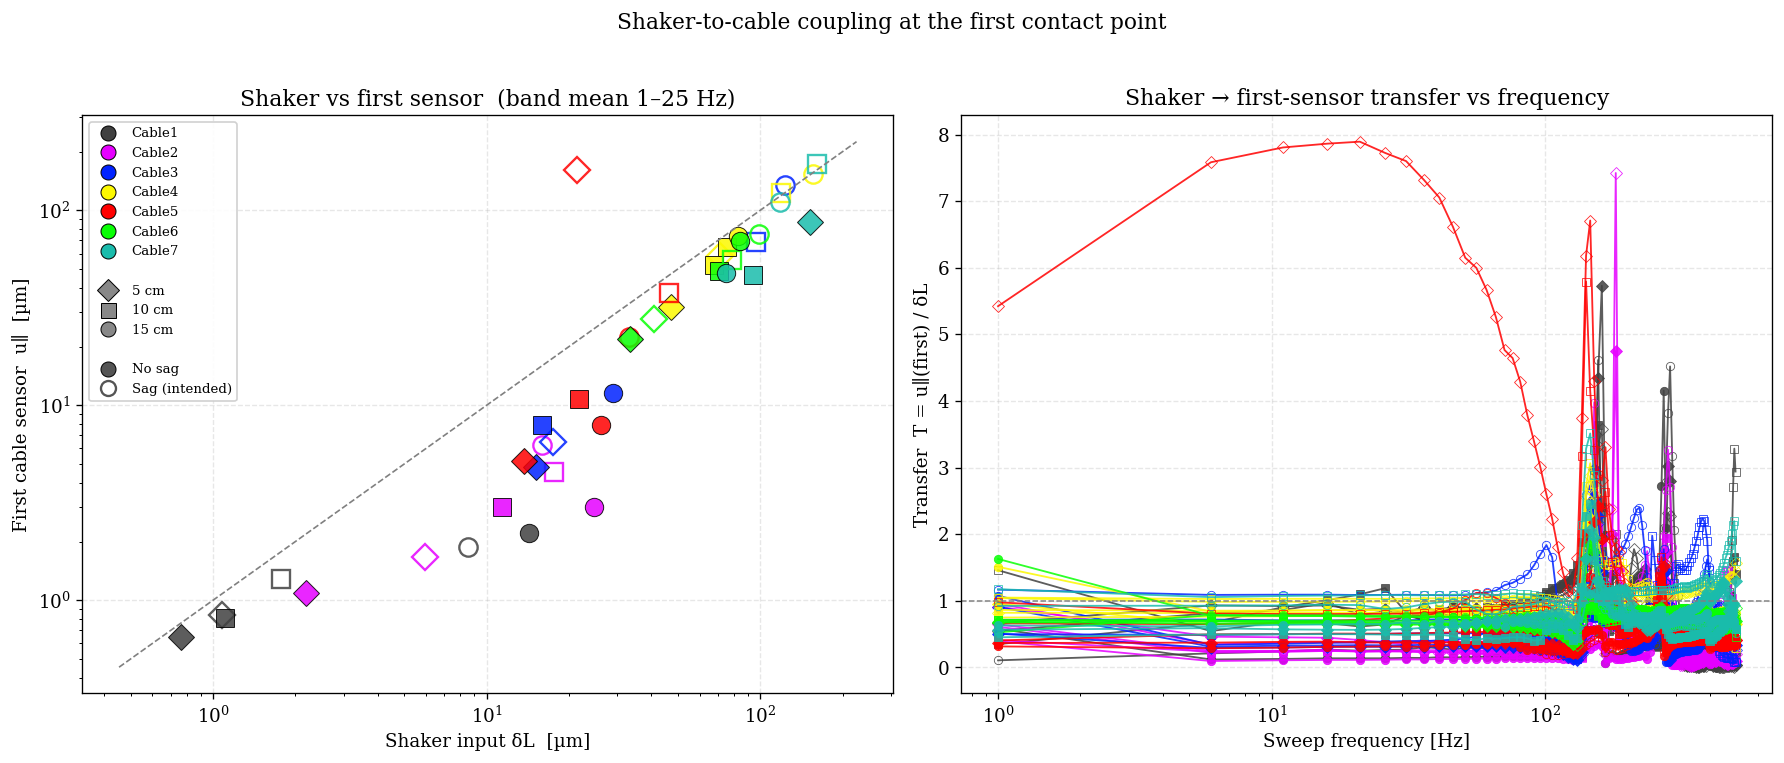

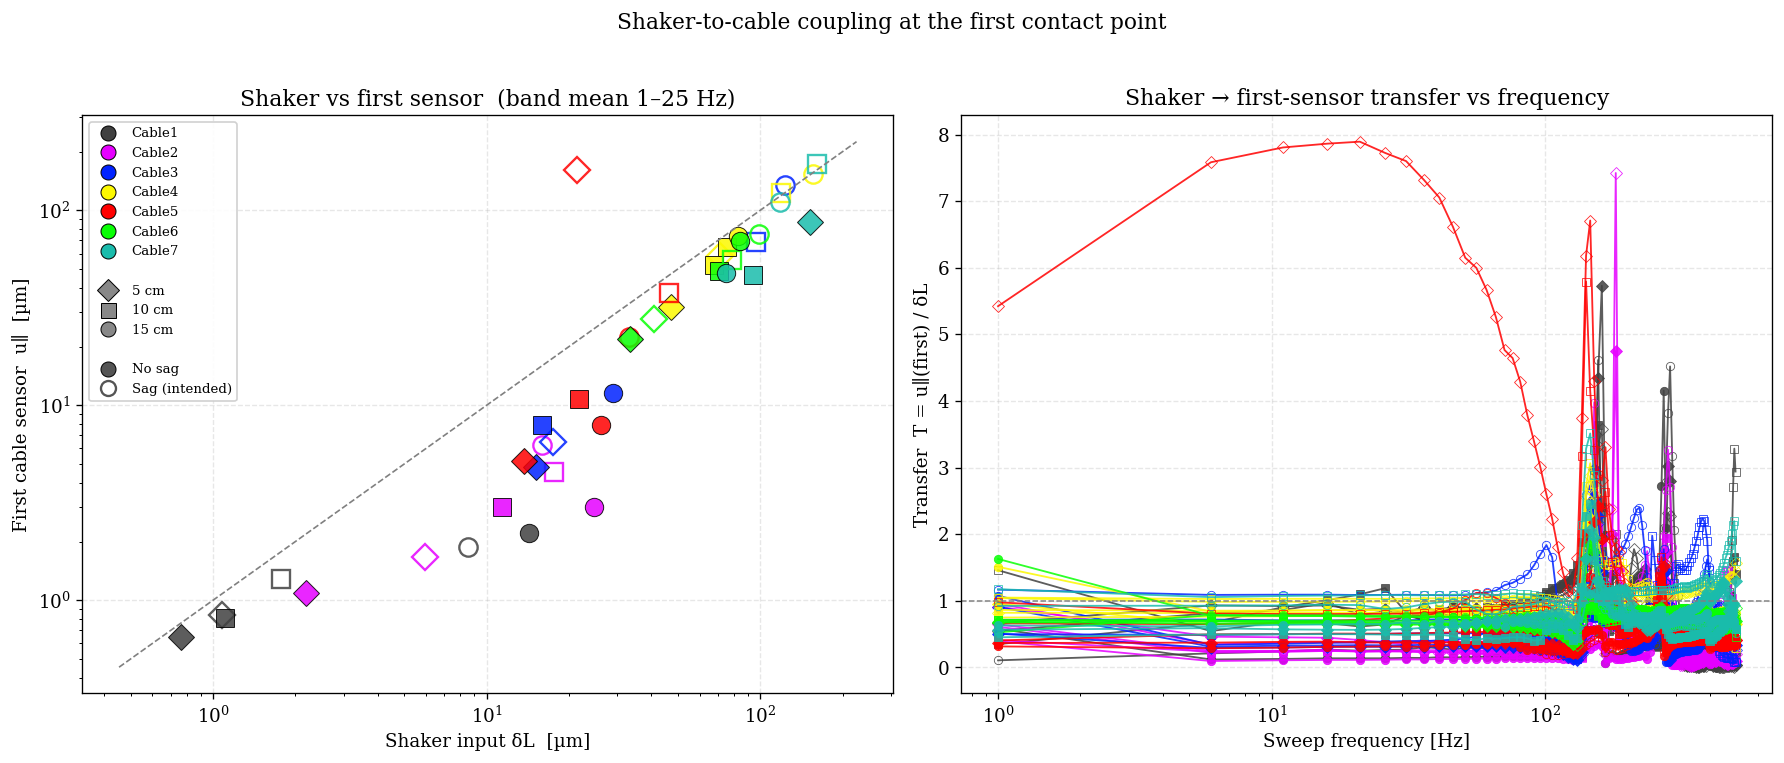

In [23]:
plotting.plot_shaker_transfer(
    DATASETS, f_min=F_MIN_LOW, f_max=F_MAX_LOW, amp_method=AMP_METHOD, freqs=freqs)


The transfer $T$ across the full band (one line per configuration).
$T<1$ means the first cable sensor moves less than the shaker (loss at the
clamp/contact); $T>1$ indicates local dynamic amplification (near a resonance).

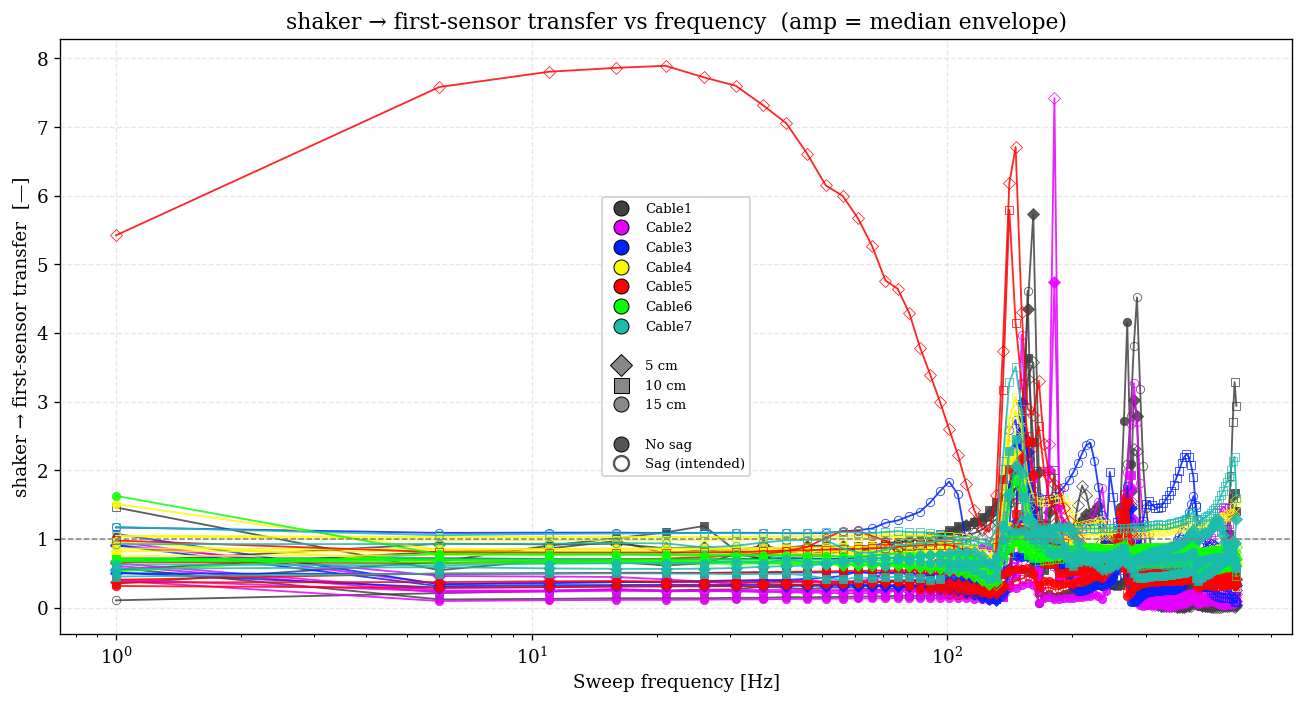

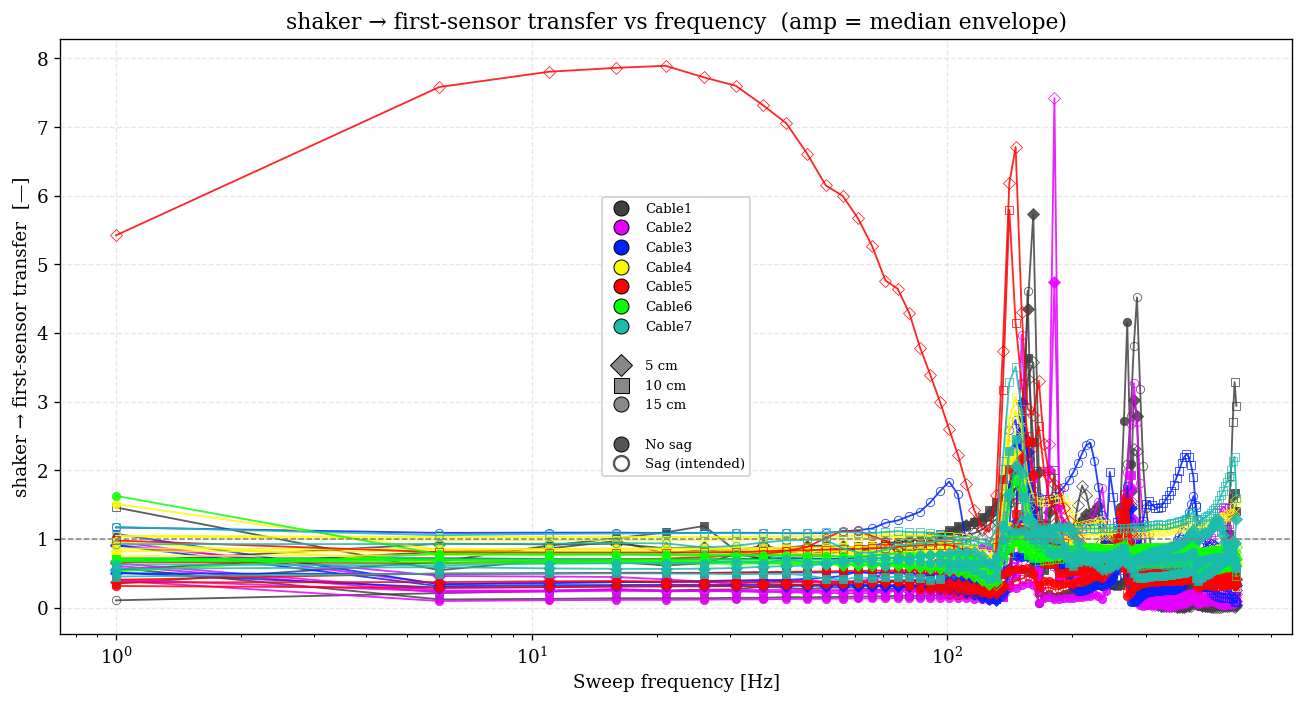

In [24]:
plotting.plot_amplitude_vs_frequency(
    DATASETS, quantity='transfer_first', amp_method=AMP_METHOD,
    logy=False, freqs=freqs)


---
## Section 8  Reference-value export

A tidy table of the band-mean amplitudes for every configuration, ready to hand
to a numerical model. Uncomment the last line to write a CSV next to the
notebook.

In [25]:
export = df_amp.copy()
display(export)

# export.to_csv('amplitude_reference_values.csv', index=False)
print('\nColumns:', list(export.columns))
print(f'{len(export)} configurations, band {F_MIN_LOW:.0f}–{F_MAX_LOW:.0f} Hz, '
      f'estimator = {AMP_METHOD}')


,Label,Cable,Gap [cm],Sag,L_ends [mm],Δu_ends [µm],± [µm],ε_ends [µε],± [µε],δL [µm],u_first [µm],T (sh→1)
0,Cable1_5cm,Cable1,5,no,42.057131,0.321911,0.141647,7.654128,3.367975,0.765662,0.647478,0.862416
1,Cable1_5cm_Sag,Cable1,5,yes,42.104090,0.592200,0.427707,14.065151,10.158315,1.077339,0.834723,0.797318
2,Cable1_10cm,Cable1,10,no,91.317868,0.704961,0.526309,7.719864,5.763481,1.109490,0.814654,0.806094
3,Cable1_10cm_Sag,Cable1,10,yes,91.270452,1.222931,0.963767,13.398980,10.559460,1.770184,1.290195,0.795616
4,Cable1_15cm,Cable1,15,no,141.207936,1.153455,0.329868,8.168483,2.336045,14.283912,2.221200,0.220241
5,Cable1_15cm_Sag,Cable1,15,yes,141.290541,1.344584,0.239755,9.516447,1.696894,8.510578,1.865665,0.215630
6,Cable2_5cm,Cable2,5,no,42.107743,0.492086,0.227564,11.686352,5.404330,2.179543,1.084104,0.536744
7,Cable2_5cm_Sag,Cable2,5,yes,42.145144,1.237253,0.533386,29.356960,12.655937,5.934769,1.659382,0.330911
8,Cable2_10cm,Cable2,10,no,91.265675,1.519152,0.374405,16.645377,4.102364,11.380446,3.006369,0.310303
9,Cable2_10cm_Sag,Cable2,10,yes,91.301391,2.839353,1.088187,31.098678,11.918626,17.605044,4.555804,0.277482



Columns: ['Label', 'Cable', 'Gap [cm]', 'Sag', 'L_ends [mm]', 'Δu_ends [µm]', '± [µm]', 'ε_ends [µε]', '± [µε]', 'δL [µm]', 'u_first [µm]', 'T (sh→1)']
42 configurations, band 1–25 Hz, estimator = median
